In [1]:
%pip -q install transformers scikit-learn

In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from pathlib import Path
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from torchvision.datasets.utils import download_and_extract_archive
from transformers import ViTImageProcessor, ViTForImageClassification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Setup

In [3]:
MODEL_NAME = "WinKawaks/vit-tiny-patch16-224"

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager"
).to(device)
model.eval()

image_size = model.config.image_size
patch_size = model.config.patch_size
grid_size = image_size // patch_size

print(f"Image size: {image_size} x {image_size}")
print(f"Patch size: {patch_size} x {patch_size}")
print(f"Patches: {grid_size} x {grid_size} = {grid_size**2}")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Image size: 224 x 224
Patch size: 16 x 16
Patches: 14 x 14 = 196


In [ ]:
DATA_ROOT = Path("./data")
DATA_DIR = DATA_ROOT / "imagenette2-160"

if not DATA_DIR.exists():
    download_and_extract_archive(
        "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz",
        download_root=str(DATA_ROOT)
    )

train_ds = ImageFolder(DATA_DIR / "train")
val_ds = ImageFolder(DATA_DIR / "val")

WNID_TO_IMAGENET_ID = {
    "n01440764": 0,
    "n02102040": 217,
    "n02979186": 482,
    "n03000684": 491,
    "n03028079": 497,
    "n03394916": 566,
    "n03417042": 569,
    "n03425413": 571,
    "n03445777": 574,
    "n03888257": 701,
}

LOCAL_TO_IMAGENET = {
    idx: WNID_TO_IMAGENET_ID[wnid]
    for wnid, idx in val_ds.class_to_idx.items()
}

def pil_collate(batch):
    images = [x[0] for x in batch]
    labels = torch.tensor([x[1] for x in batch])
    return images, labels

print(len(train_ds), len(val_ds))

100%|██████████| 99.0M/99.0M [00:02<00:00, 40.0MB/s]


9469 3925


## 1. Pre-trained ViT Classification

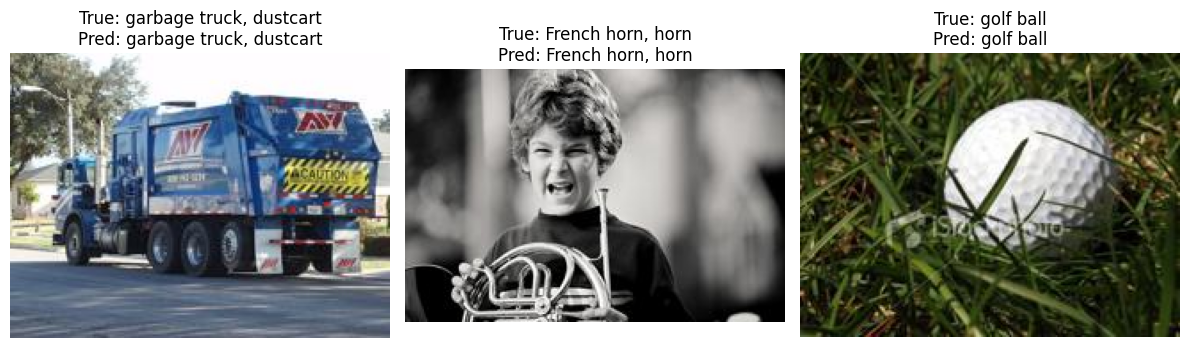

In [5]:
rng = np.random.default_rng(0)
sample_indices = rng.choice(len(val_ds), size=3, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, idx in zip(axes, sample_indices):
    image, local_label = val_ds[int(idx)]
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        logits = model(**inputs).logits

    pred_id = logits.argmax(dim=-1).item()
    pred_label = model.config.id2label[pred_id]
    true_id = LOCAL_TO_IMAGENET[local_label]
    true_label = model.config.id2label[true_id]

    ax.imshow(image)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. Patch Attention Visualization

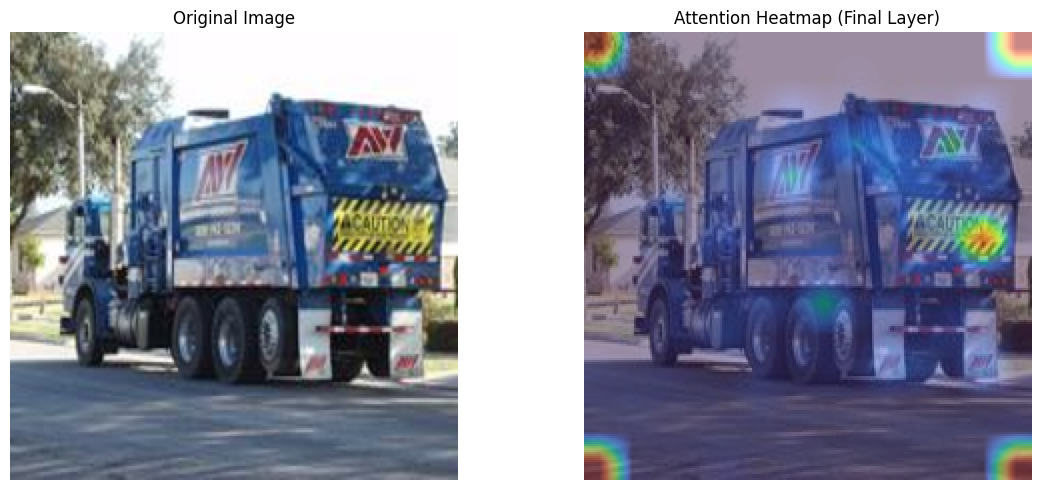

In [9]:
image, _ = val_ds[int(sample_indices[0])]
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)
    pred_id = outputs.logits.argmax(dim=-1).item()

pred_label = model.config.id2label[pred_id]

final_attention = outputs.attentions[-1]

cls_attention = final_attention.mean(dim=1)[0, 0, 1:]
assert cls_attention.numel() == grid_size**2

attention_map = cls_attention.reshape(grid_size, grid_size)
attention_map = F.interpolate(
    attention_map[None, None],
    size=(image_size, image_size),
    mode="bilinear",
    align_corners=False
)[0, 0].cpu()

attention_map = (attention_map - attention_map.min()) / (
    attention_map.max() - attention_map.min() + 1e-8
)

display_image = image.resize((image_size, image_size))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(display_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(display_image)
axes[1].imshow(
    attention_map,
    cmap="turbo",
    alpha=0.48,
    vmin=0,
    vmax=1
)
axes[1].set_title("Attention Heatmap (Final Layer)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

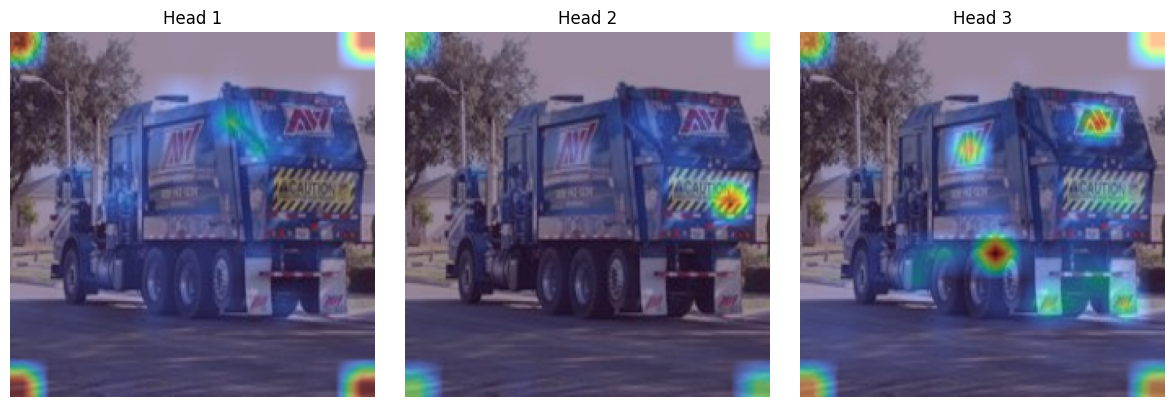

In [11]:
num_heads = final_attention.shape[1]

fig, axes = plt.subplots(1, num_heads, figsize=(4*num_heads, 4))

for h, ax in enumerate(np.atleast_1d(axes)):
    head_attn = final_attention[0, h, 0, 1:]
    head_map = head_attn.reshape(grid_size, grid_size)

    head_map = F.interpolate(
        head_map[None, None],
        size=(image_size, image_size),
        mode="bilinear",
        align_corners=False
    )[0, 0].cpu()

    ax.imshow(display_image)
    ax.imshow(head_map, cmap="turbo", alpha=0.5)
    ax.set_title(f"Head {h+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Patch-Masking Experiment

{'Original': 0.868, 'Random 25%': 0.766, 'Center 25%': 0.476}


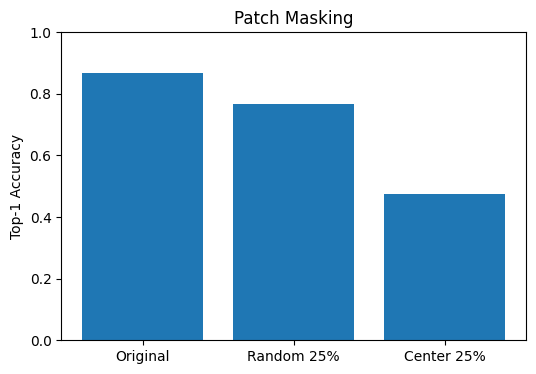

In [7]:
def mask_patches(pixel_values, fraction=0.25, mode="random"):
    x = pixel_values.clone()
    b, _, h, w = x.shape
    gh, gw = h // patch_size, w // patch_size
    n_patches = gh * gw
    n_mask = int(round(fraction * n_patches))

    coords = torch.stack(
        torch.meshgrid(torch.arange(gh), torch.arange(gw), indexing="ij"),
        dim=-1
    ).reshape(-1, 2)

    center = torch.tensor([(gh - 1) / 2, (gw - 1) / 2])
    center_order = ((coords.float() - center) ** 2).sum(dim=1).argsort()

    for i in range(b):
        if mode == "random":
            selected = torch.randperm(n_patches)[:n_mask]
        elif mode == "center":
            selected = center_order[:n_mask]
        else:
            raise ValueError("mode must be 'random' or 'center'")

        for p in selected:
            r = int(p) // gw
            c = int(p) % gw
            x[i, :, r*patch_size:(r+1)*patch_size,
                 c*patch_size:(c+1)*patch_size] = 0

    return x


@torch.no_grad()
def evaluate_masking(mode=None, fraction=0.25, max_images=500, batch_size=32):
    loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=pil_collate
    )

    correct = 0
    total = 0

    for images, local_labels in loader:
        if total >= max_images:
            break

        keep = min(len(images), max_images - total)
        images = images[:keep]
        local_labels = local_labels[:keep]

        pixel_values = processor(
            images=images,
            return_tensors="pt"
        ).pixel_values

        if mode is not None:
            pixel_values = mask_patches(pixel_values, fraction, mode)

        logits = model(pixel_values=pixel_values.to(device)).logits
        preds = logits.argmax(dim=-1).cpu()

        targets = torch.tensor([
            LOCAL_TO_IMAGENET[int(y)] for y in local_labels
        ])

        correct += (preds == targets).sum().item()
        total += keep

    return correct / total


mask_results = {
    "Original": evaluate_masking(),
    "Random 25%": evaluate_masking("random", 0.25),
    "Center 25%": evaluate_masking("center", 0.25),
}

print(mask_results)

plt.figure(figsize=(6, 4))
plt.bar(mask_results.keys(), mask_results.values())
plt.ylabel("Top-1 Accuracy")
plt.title("Patch Masking")
plt.ylim(0, 1)
plt.show()

## 5. CLS Token vs. Mean-Pooled Patch Tokens

{'CLS Token': 0.976, 'Mean Patches': 0.95}


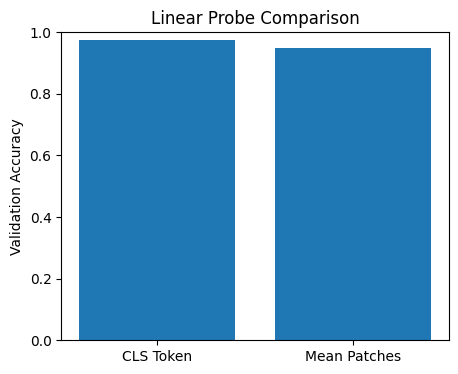

In [8]:
@torch.no_grad()
def extract_probe_features(dataset, n_samples, seed=0, batch_size=32):
    rng = np.random.default_rng(seed)
    indices = rng.choice(
        len(dataset),
        size=min(n_samples, len(dataset)),
        replace=False
    )

    loader = DataLoader(
        Subset(dataset, indices),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=pil_collate
    )

    cls_features = []
    mean_features = []
    labels = []

    for images, y in loader:
        pixel_values = processor(
            images=images,
            return_tensors="pt"
        ).pixel_values.to(device)

        tokens = model.vit(pixel_values=pixel_values).last_hidden_state

        cls_features.append(tokens[:, 0].cpu())
        mean_features.append(tokens[:, 1:].mean(dim=1).cpu())
        labels.append(y)

    return (
        torch.cat(cls_features).numpy(),
        torch.cat(mean_features).numpy(),
        torch.cat(labels).numpy()
    )


X_train_cls, X_train_mean, y_train = extract_probe_features(
    train_ds, n_samples=1500, seed=0
)
X_val_cls, X_val_mean, y_val = extract_probe_features(
    val_ds, n_samples=500, seed=1
)

probe_cls = LogisticRegression(max_iter=1000)
probe_mean = LogisticRegression(max_iter=1000)

probe_cls.fit(X_train_cls, y_train)
probe_mean.fit(X_train_mean, y_train)

cls_acc = accuracy_score(y_val, probe_cls.predict(X_val_cls))
mean_acc = accuracy_score(y_val, probe_mean.predict(X_val_mean))

probe_results = {
    "CLS Token": cls_acc,
    "Mean Patches": mean_acc,
}

print(probe_results)

plt.figure(figsize=(5, 4))
plt.bar(probe_results.keys(), probe_results.values())
plt.ylabel("Validation Accuracy")
plt.title("Linear Probe Comparison")
plt.ylim(0, 1)
plt.show()